In [1]:
req.libs <- c("data.table", "dplyr", "ggplot2", "scattermore", 
              "stringi", "tidyr", "viridis", "Matrix", "tibble", "ComplexHeatmap", "circlize")
lapply(req.libs, function(x){
    suppressMessages(library(x, character.only = TRUE))})

[[1]]
[1] "data.table" "stats"      "graphics"   "grDevices"  "utils"     
[6] "datasets"   "methods"    "base"      

[[2]]
[1] "dplyr"      "data.table" "stats"      "graphics"   "grDevices" 
[6] "utils"      "datasets"   "methods"    "base"      

[[3]]
 [1] "ggplot2"    "dplyr"      "data.table" "stats"      "graphics"  
 [6] "grDevices"  "utils"      "datasets"   "methods"    "base"      

[[4]]
 [1] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
 [6] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[11] "base"       

[[5]]
 [1] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
 [6] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[11] "methods"     "base"       

[[6]]
 [1] "tidyr"       "stringi"     "scattermore" "ggplot2"     "dplyr"      
 [6] "data.table"  "stats"       "graphics"    "grDevices"   "utils"      
[11] "datasets"    "methods"     "base"       

[[7]]
 [1] "viridis"     "viridisLite" "tidyr"       "stringi"     "scattermore"
 [6] "ggplot2"     "dplyr"       "data.table"  "stats"       "graphics"   
[11] "grDevices"   "utils"       "datasets"    "methods"     "base"       

[[8]]
 [1] "Matrix"      "viridis"     "viridisLite" "tidyr"       "stringi"    
 [6] "scattermore" "ggplot2"     "dplyr"       "data.table"  "stats"      
[11] "graphics"    "grDevices"   "utils"       "datasets"    "methods"    
[16] "base"       

[[9]]
 [1] "tibble"      "Matrix"      "viridis"     "viridisLite" "tidyr"      
 [6] "stringi"     "scattermore" "ggplot2"     "dplyr"       "data.table" 
[11] "stats"       "graphics"    "grDevices"   "utils"       "datasets"   
[16] "methods"     "base"       

[[10]]
 [1] "ComplexHeatmap" "grid"           "tibble"         "Matrix"        
 [5] "viridis"        "viridisLite"    "tidyr"          "stringi"       
 [9] "scattermore"    "ggplot2"        "dplyr"          "data.table"    
[13] "stats"          "graphics"       "grDevices"      "utils"         
[17] "datasets"       "methods"        "base"          

[[11]]
 [1] "circlize"       "ComplexHeatmap" "grid"           "tibble"        
 [5] "Matrix"         "viridis"        "viridisLite"    "tidyr"         
 [9] "stringi"        "scattermore"    "ggplot2"        "dplyr"         
[13] "data.table"     "stats"          "graphics"       "grDevices"     
[17] "utils"          "datasets"       "methods"        "base"

In [2]:
donor.files <- "/mnt/users/rachelsavage/paper_minimorf/data/donor_calling/final_donor_calls"
donor.files <- list.files(donor.files, full.names = TRUE)[grepl("*donor.assign.txt", list.files(donor.files))]
donor.df <- lapply(donor.files, fread)
donor.df <- do.call(rbind, donor.df)

In [3]:
head(donor.df)

cell,num_snps,num_umis,ratio,pvalue,FDR_pvalue,bestLikelihood,bestSample,median_likelihood,population_average_likelihood,donor1,donor2,donor3
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
GCAATCCGTGTACCTTGTTAGCCT_SS-PKR-608,82,96,5.7634,1.7242e-06,1.9379e-06,-69.5690,donor3,-75.332,-45.457,-116.340,-75.332,-69.5690
GCAACATTGATTCATCTACAGGAT_SS-PKR-608,14,15,3.9999,1.0002e-04,1.0815e-04,-6.1075,donor3,-10.107,-7.327,-21.630,-10.107,-6.1075
GTGTGTCGGAGCCAATTATGCCAG_SS-PKR-608,102,118,47.1660,6.8208e-48,3.3551e-47,-72.6180,donor1,-119.780,-52.717,-72.618,-123.550,-119.7800
TATGTGGCTGTGGTTGGATAGAGG_SS-PKR-608,39,49,40.7110,1.9469e-41,7.3117e-41,-9.4363,donor3,-50.147,-14.629,-53.726,-50.147,-9.4363
GAATCTGTTTGACTCTGTACATCT_SS-PKR-608,201,247,130.0900,8.1072e-131,1.8113e-128,-56.3780,donor3,-186.470,-56.725,-222.070,-186.470,-56.3780
CTTGTACTTATGTGGCGGAATGAT_SS-PKR-608,64,67,34.1860,6.5169e-35,1.8564e-34,-22.2720,donor1,-56.458,-20.520,-22.272,-65.545,-56.4580


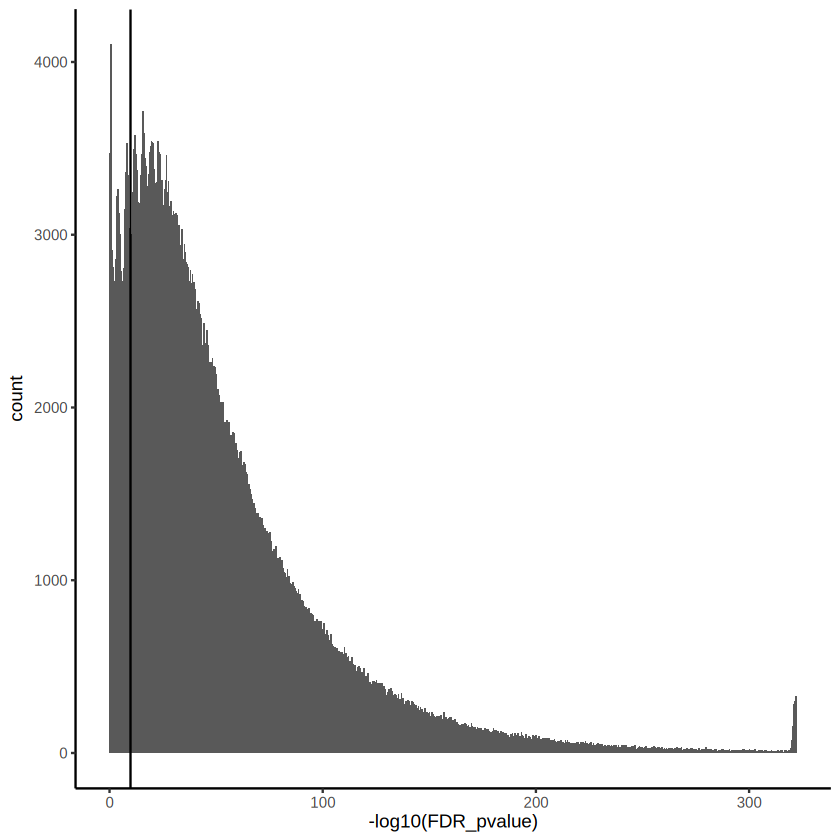

In [4]:
ggplot(donor.df, aes(x=-log10(FDR_pvalue)))+
  geom_histogram(bins = 1000)+
theme_classic()+
geom_vline(xintercept = 10)

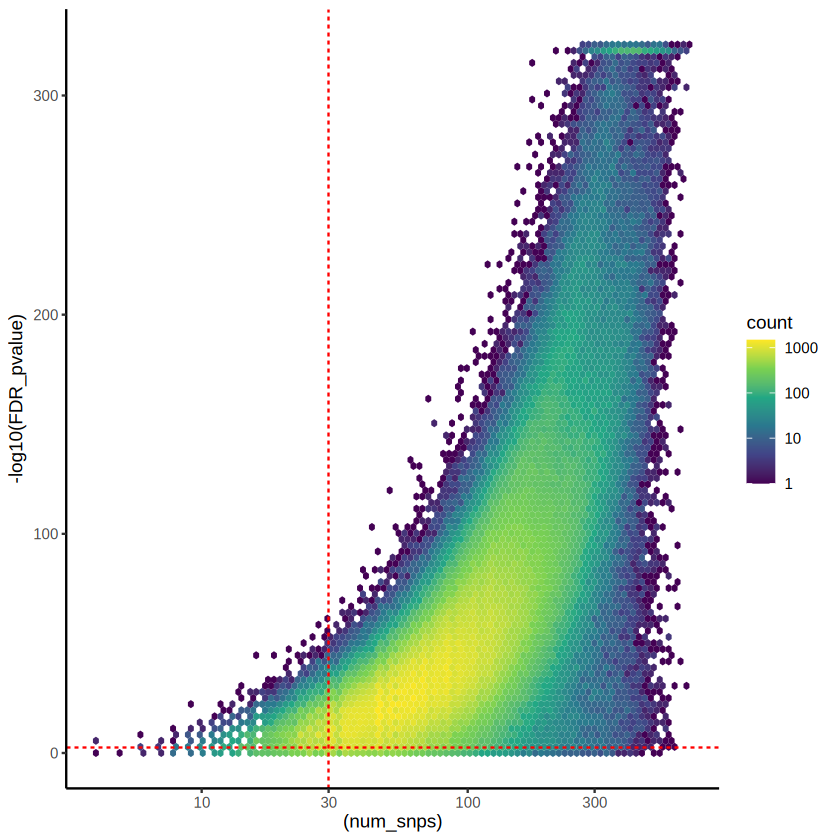

In [5]:
snp.cutoff <- 30
fdr.cutoff <- 0.005

ggplot(donor.df, aes(x=(num_snps), y=-log10(FDR_pvalue)))+
stat_bin_hex(bins = 100)+
scale_x_continuous(trans = "log10")+
theme_classic()+
scale_fill_viridis_c(trans = "log10")+
geom_hline(yintercept = -log10(fdr.cutoff),linetype = "dashed", color = "red")+
geom_vline(xintercept = snp.cutoff,linetype = "dashed", color = "red")

In [6]:
dim(donor.df)
donor.df.filt <- donor.df %>% filter(num_snps>= snp.cutoff) %>% 
filter(FDR_pvalue <= fdr.cutoff) 

[1] 762374     13

In [28]:
fwrite(donor.df.filt, "/mnt/users/rachelsavage/paper_minimorf/data/donor_calling/filt.donor.txt")

In [83]:
doublet_df <- donor.df.filt %>% pivot_longer(cols = c("donor1", "donor2", "donor3"), 
                                        names_to = "donor", values_to = "donor_bestlikelihood") %>%
group_by(cell) %>% 
arrange(-donor_bestlikelihood) %>% 
mutate(rank = row_number())%>%
dplyr::select(bestSample, num_snps, cell, rank, donor_bestlikelihood)%>%
pivot_wider(names_from = "rank", values_from = "donor_bestlikelihood")
colnames(doublet_df) <- c("bestSample", "num_snps", "barcode", "bestLikelihood_1", "bestLikelihood_2", "bestLikelihood_3")
doublet_df<-doublet_df %>%
mutate(difference = abs(bestLikelihood_1 - bestLikelihood_2))

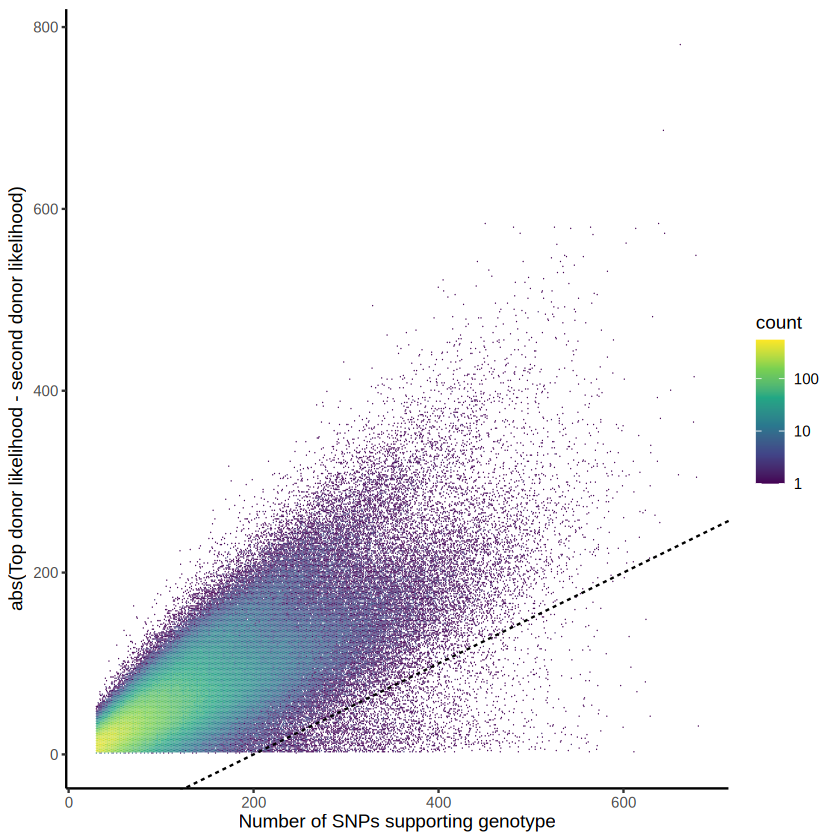

In [101]:
slope <- 0.5
intercept <- -100

doublet_df %>%
#filter(difference<400)%>%
ggplot(aes(x=num_snps,y=difference))+
stat_bin_hex(bins = 500)+
theme_classic()+
scale_fill_viridis_c(trans = "log10")+
geom_abline(slope = slope, intercept = intercept, linetype = "dashed")+
xlab("Number of SNPs supporting genotype")+
ylab("abs(Top donor likelihood - second donor likelihood)")

In [102]:
df_under_line <- doublet_df %>%
  filter(difference < (slope * num_snps + intercept))
dim(doublet_df)
dim(df_under_line)
nrow(df_under_line) /  nrow(doublet_df)
doublet_barcodes <- df_under_line$barcode
length(doublet_barcodes)

[1] 705728      7

[1] 3414    7

[1] 0.004837558

[1] 3414

In [105]:
donor.df.filt$doublet <- "no"
donor.df.filt$doublet[donor.df.filt$cell %in% doublet_barcodes] <- "yes"
table(donor.df.filt$doublet)
fwrite(donor.df.filt, "/mnt/users/rachelsavage/paper_minimorf/data/donor_calling/filt.donor.txt")


    no    yes 
702314   3414 